<a href="https://colab.research.google.com/github/aditi-tawade-ai/aditi-tawade-ai/blob/main/Notebook/Day_25_model_deplymt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **start again with same process did earlier for splitting data**

In [ ]:
import pandas as pd
car = pd.read_csv('/content/mtcars.csv')
car[:3]

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1


In [ ]:
# take cyl,disp,hp,wt for making a model

In [ ]:
# preprocessing of data
# checking if any missing values
car.isna().sum()

,0
mpg,0
cyl,0
disp,0
hp,0
drat,0
wt,0
qsec,0
vs,0
am,0
gear,0


<Axes: >

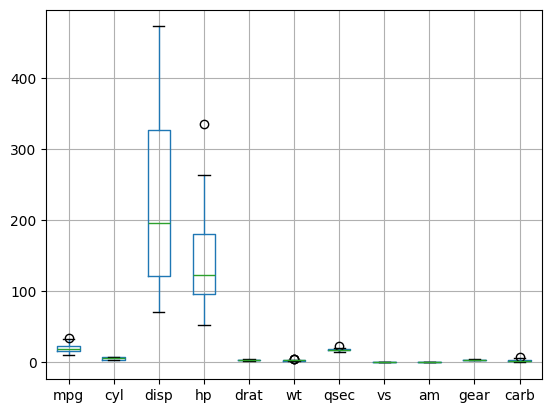

In [ ]:
# checking noise/outliers
car.boxplot()

<Axes: >

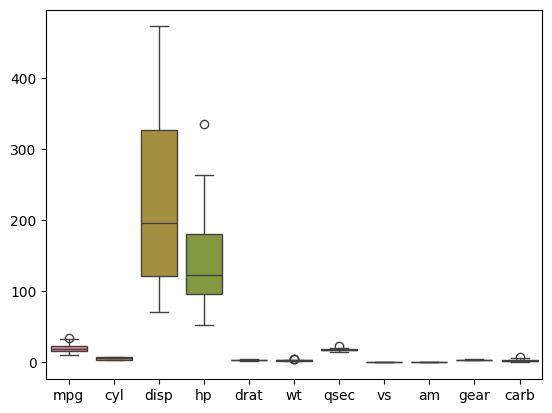

In [ ]:
# or using seaborn
import seaborn as sns
sns.boxplot(data = car)

In [ ]:
# analysis of data use pairplot

In [ ]:
X_a = car[['mpg','cyl','disp','hp','wt']]
# y_a = car['mpg']

In [ ]:
test1 = X_a

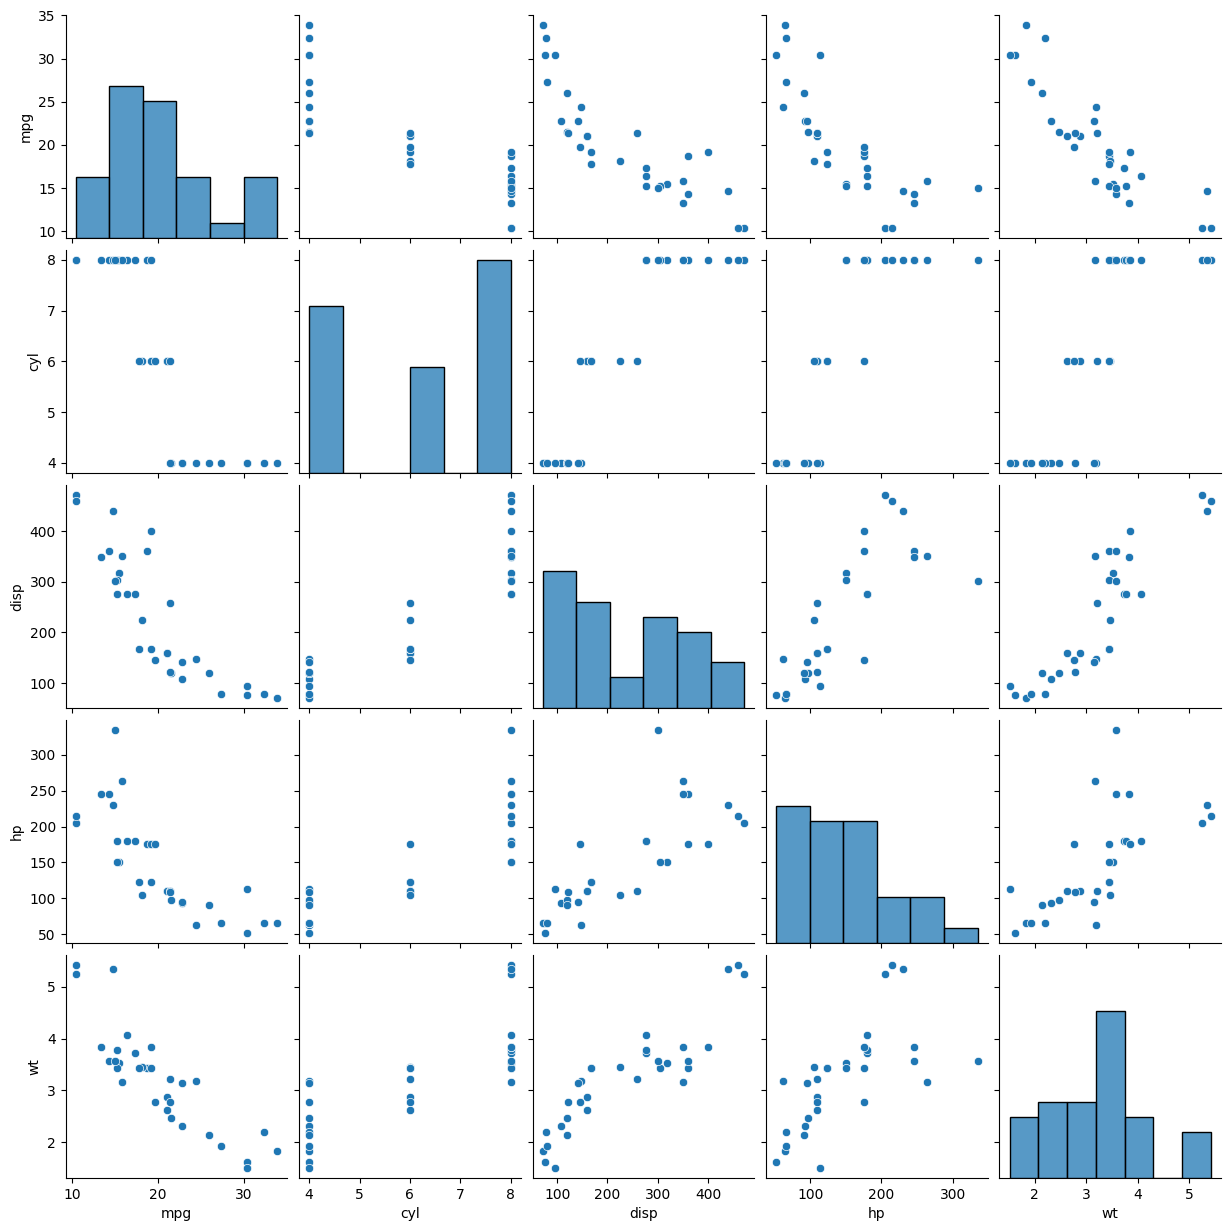

In [ ]:
sns.pairplot(data = test1)

In [ ]:
test1.corr()

,mpg,cyl,disp,hp,wt
mpg,1.000000,-0.852162,-0.847551,-0.776168,-0.867659
cyl,-0.852162,1.000000,0.902033,0.832447,0.782496
disp,-0.847551,0.902033,1.000000,0.790949,0.887980
hp,-0.776168,0.832447,0.790949,1.000000,0.658748
wt,-0.867659,0.782496,0.887980,0.658748,1.000000


- from above data we can see that input factors are -vly linear correlated

In [ ]:
# splitting the data
from sklearn.model_selection import train_test_split

In [ ]:
X = car[['cyl','disp','wt','hp']]
y = car['mpg']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2)
X_train[:2]

,cyl,disp,wt,hp
27,4,95.1,1.513,113
7,4,146.7,3.190,62


In [ ]:
X_test[:2]

,cyl,disp,wt,hp
2,4,108.0,2.32,93
29,6,145.0,2.77,175


In [ ]:
len(X_train)

25

In [ ]:
len(X_test)

7

In [ ]:
# training
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model

LinearRegression()

In [ ]:
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
# checking data score
model.score(X_train,y_train),model.score(X_test,y_test)

(0.8616744681904838, 0.5532581436182261)

- good to go further

In [ ]:
# testing
test = X_test
test

,cyl,disp,wt,hp
2,4,108.0,2.320,93
29,6,145.0,2.770,175
25,4,79.0,1.935,66
1,6,160.0,2.875,110
4,8,360.0,3.440,175
28,8,351.0,3.170,264
24,8,400.0,3.845,175


In [ ]:
# predicted value
y_pred = model.predict(test)
y_pred

array([26.58461425, 21.36415991, 28.11839379, 21.83138638, 16.86551541,
       16.67890719, 15.61756558])

In [ ]:
# Regression matrices
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [ ]:
mean_absolute_error(y_test,y_pred)

1.9134829314046284

In [ ]:
mean_squared_error(y_test,y_pred)

5.0607646865386755

In [ ]:
r2_score(y_test,y_pred)

0.5532581436182261

In [ ]:
X[:2]

,cyl,disp,wt,hp
0,6,160.0,2.620,110
1,6,160.0,2.875,110


In [ ]:
y[:2]

,mpg
0,21.0
1,21.0


In [ ]:
X_train[:5]

,cyl,disp,wt,hp
27,4,95.1,1.513,113
7,4,146.7,3.190,62
15,8,460.0,5.424,215
16,8,440.0,5.345,230
11,8,275.8,4.070,180


In [ ]:
# Assume this is a good model
# Deployment
# Serialization Process --> convert python code to object/Byte code

In [ ]:
model

LinearRegression()

In [ ]:
# perform pickling to convert the code in byte form
import pickle

pickle.dump(model,open('model.pkl','wb'))